# Introduction

This tutorial explains the components of photometry traces and how to rigoriously simulate them using the ``SimulatedPhotometry`` class. 

# 1. Background

Photometry data is measuring photons from an excited fluorophore in the brain, usually a detector protein that binds to a small molecule of interest, and whose expression is induced via engineered virus or transgene.

Therefore the flourescence measured is roughly given by:

$$
F(\lambda) = 
f(\theta) g(\lambda) 
\cdot \phi_{F} I_{ex} 
\cdot \epsilon_{\lambda} b \, \mathbf{c}
$$

Where:

* $f(\theta)=$ collection efficiency
* $g(\lambda)=$ efficiency of detector
* $\phi_F=$ quantum yield of the fluorophore
* $I_{ex}=$ excitation wavelength intensity
* $\epsilon_\lambda=$ molar extinction coefficient
* $b=$ optical path length
* $\mathbf{c}=$ **fluorophore concentation**

The combination of $\phi_{F} \cdot \epsilon_{\lambda}$ can be thought of as the "molecular brightness".

Generally, the fluorophore is engineered to have a distinct excitation wavelength when it is bound to its ligand. The general scheme is:

$$
P_b \leftarrow P_{ex} \longleftrightarrow
P \rightleftharpoons PL
\longleftrightarrow PL_{ex} \rightarrow PL_b
$$

Where:

* $P=$ unbound protein
* $PL=$ ligand-protein complex
* $X_{ex}=$ excited state
* $X_b=$ bleached state

<br>

An ideal fluorophore will have the following properties: 

* At the *experimental* wavelength ($\lambda_{exp}$): $\quad \phi_{PL} \cdot \epsilon_{PL} \gg \phi_{P} \cdot \epsilon_P$
* At the *isosbestic* wavelength ($\lambda_{iso}$): $\quad \phi_{PL} \cdot \epsilon_{PL} = \phi_{P} \cdot \epsilon_P$


This means at $\lambda_{exp}$, $F(\lambda_{exp})$ is unaffected by the concentration of the unbound protein $[P]$. And at $\lambda_{iso}$, $F(\lambda_{iso})$ is agnostic to the concentration of the ligand $[L]$. This is why $F(\lambda_{iso})$ can be used to correct for photobleaching attenuation and other artifacts without the signal from the true changes in $[PL]$ and thus $[L]$.

With this background knowledge, we can breakdown photometry traces into its requisite components:

 1. **Neural trace, the "true signal"**
    * The changes in $F(\lambda_{exp})$ representing the fluctuations $[L]$.

<br>

2. **Photobleaching attenuation**
    * The irreversible process of $P_{ex} \rightarrow P_b$, decreasing overall signal over time.

<br>

3. **Detector and electronic noise**
    * Guassian noise of constant magnitude over time originating from the electronic components of the detector device.

<br>

4. **Photonic noise**
    * Possion noise with magnitude $\propto \sqrt{N_{\text{photons}}}$, so roughly $\propto \sqrt{I}$ if $I \propto N_{\text{photons}}$.

<br>

5. **Attenuation artifacts**
    * Both movement and hemodynamic artifacts that decrease the precentage of light transmitance.
    * Most movement artifacts come from the bending of the fiber optic cable, which causes some light to be not be internally reflected and "lost".

<br>

6. **Background autofluorecence**
    * The fluorecent response of the tissue and fiber.

# 2. The Simulation Model

This package simulates photometry traces by modeling the above components of photometry traces with the following layers:

``TimeBase``: is used to create the time series of the traces.

1. **Neural trace, the "true signal"**
    * ``EventLayer`` ($\mathbf{E}$): the true neural signals in response to event stimuli.

    * ``NeuralDynamicNoiseLayer`` ($\mathbf{D}$): the noise in the true fluctuation of $[L]$, usually of a lower frequency than the sampling frequency.

<br>

2. **Photobleaching attenuation** & 6. **background autofluorecence**
    * ``PhotobleachingLayer`` ($\mathbf{B}$): models photobleaching with a negative bi-exponential equation that also captures background autofluorecence in ($\beta_{\text{floor}}$):

$$
\alpha_{1} e^{-t / \tau_1} + \alpha_2 e^{-t / \tau_2} + \beta_{\text{floor}}
$$

<br>

3. **Detector and electronic noise**
    * ``NoiseGaussianLayer`` ($\mathbf{N_g}$): Gaussian noise of constant magnitude over time.

<br>

4. **Photonic noise**
    * ``NoiseShotLayer`` ($\mathbf{N_s}$): Possion noise with magnitude $\propto \sqrt{I \times \text{photons-per-unit}}$

<br>

5. **Attenuation artifacts**
    * ``MovementAttenuationLayer`` ($\mathbf{M}$): low-frequency movement attenuation representing baseline movement, generated by low-pass filtering gaussian noise.

    * ``ArtifactSpikeLayer`` ($\mathbf{AS}$): sharp pings that readily return to baseline, that represent sharp bends in the fiber optic cable, which have been observed in real data.

    * ``ArtifactJumpLayer`` ($\mathbf{AJ}$): sharp changes in the baseline value of signal for an extended period, which have been observed in real data.

Then the **experimental trace** is calculated by:

* $\text{Clean Trace} \, (\mathbf{C}) = \mathbf{B} \cdot (\mathbf{E} + \mathbf{D}) + \mathbf{B}$

* $\text{Artifact} \, (\mathbf{A}) = \mathbf{M} \cdot \mathbf{AS} \cdot \mathbf{AJ}$

* $\text{Noise} \, (\mathbf{N}) = \mathbf{N_g} + \mathbf{N_s}(\mathbf{C})$

* $F(\lambda_{exp}) = \mathbf{C} \cdot \mathbf{A} + \mathbf{N}$

And the **isosbestic trace** is calculated by:

* $\text{Clean Trace} \, (\mathbf{C_{iso}}) = \mathbf{B_{iso}} \cdot \text{c}_{\text{iso-leakage}} (\mathbf{E} + \mathbf{D}) + \mathbf{B_{iso}}$

* $\text{Artifact} \, (\mathbf{A}) = \mathbf{M} \cdot \mathbf{AS} \cdot \mathbf{AJ}$

* $\text{Noise} \, (\mathbf{N_{iso}}) = \mathbf{N_{g,iso}} + \mathbf{N_{s,iso}}(\mathbf{C_{iso}})$

* $F(\lambda_{iso}) = \mathbf{C_{iso}} \cdot \mathbf{A} + \mathbf{N_{iso}}$

Where $\mathbf{B}$ and $\mathbf{N}$ are calculated seperately from the experimental trace and $\mathbf{A}$ is shared between experimental and isosbestic traces. 

While the ideal isosbestic wavelength will not contain any neural trace, this package supports simulating a non-ideal isosbestic wavelength with the parameter ``iso_event_leakage`` which controls how much the "true signal" leaks into the isosbestic trace. It is roughly equivalent to $\phi_{PL} \cdot \epsilon_{PL} - \phi_{P} \cdot \epsilon_P$ at the isosobestic wavelength. 

If ``iso_event_leakage == 0``, the isosbestic wavelength is ideal and $[L]$ does not affect $F(\lambda_{iso})$. If``iso_event_leakage > 0``, the bound protein is "brighter" than the unbound protein at $\lambda_{iso}$ and a positive change in $[L]$, and thus $F(\lambda_{exp})$, causes a positive transient in $F(\lambda_{iso})$. Likewise, if ``iso_event_leakage < 0``, a positive change in $[L]$ causes a negative transient in $F(\lambda_{iso})$.

# 3. Simulating Photometry

In this package, we can simulate photometry using the ``SimulatedPhotometry`` class.

``SimulatedPhotometry`` can either be built directly from the layers in ``PhoPro.sim.layers`` or, most conviently, from parameters using ``.from_parameters()``.

In [2]:
# import important packages
import numpy as np
import pandas as pd
from plotnine import * # type: ignore

from PhoPro import SimulatedPhotometry

In [3]:
sim = SimulatedPhotometry.from_parameters(
    # length of experiment and sampling rate
    length_sec=1000,
    frequency=100,

    # parameters of photobleaching curves
    bleaching_params_exp = { 'alpha1': 50, 'alpha2': 20, 'tau1': 300, 'tau2': 10000, 'B_floor': 10 },
    bleaching_params_iso = { 'alpha1': 45, 'alpha2': 18, 'tau1': 300, 'tau2': 10000, 'B_floor': 8 },

    # you can alternatively make the photobleaching curve 
    #   of the isosbestic by scaling that of the experimental
    iso_bleach_scale=None,

    # optional evenly spaced event of the E layer
    n_events=None,

    # magnitude and frequency of the M layer
    movement_attenuation=0.3,
    attenuation_cutoff_hz=0.1,

    # magnitude of the Ns layer
    photons_per_unit=1e4,

    # magnitude of the Ng layer
    gaussian_noise_scale=0.2,

    # magnitude, offset, and frequency of the D layer
    dynamic_noise_amplitude=0.001,
    dynamic_noise_center=0.0,
    dynamic_noise_frequency=1.0,

    # controls for the AS layer
    n_spike_artifacts=5,
    spike_amplitude_range=(-0.5, -0.2),

    # controls for the AJ layer
    n_jump_artifacts=2,
    jump_amplitude_range=(0.3, 0.35),
    jump_duration_range=(100, 200),

    # reproducible rng
    seed=102,

    # isosbestic leakage control
    iso_event_leakage=None,
)

We can visualize the trace components and the final composite traces using ``.plot_layers()`` and ``.plot_traces()``.

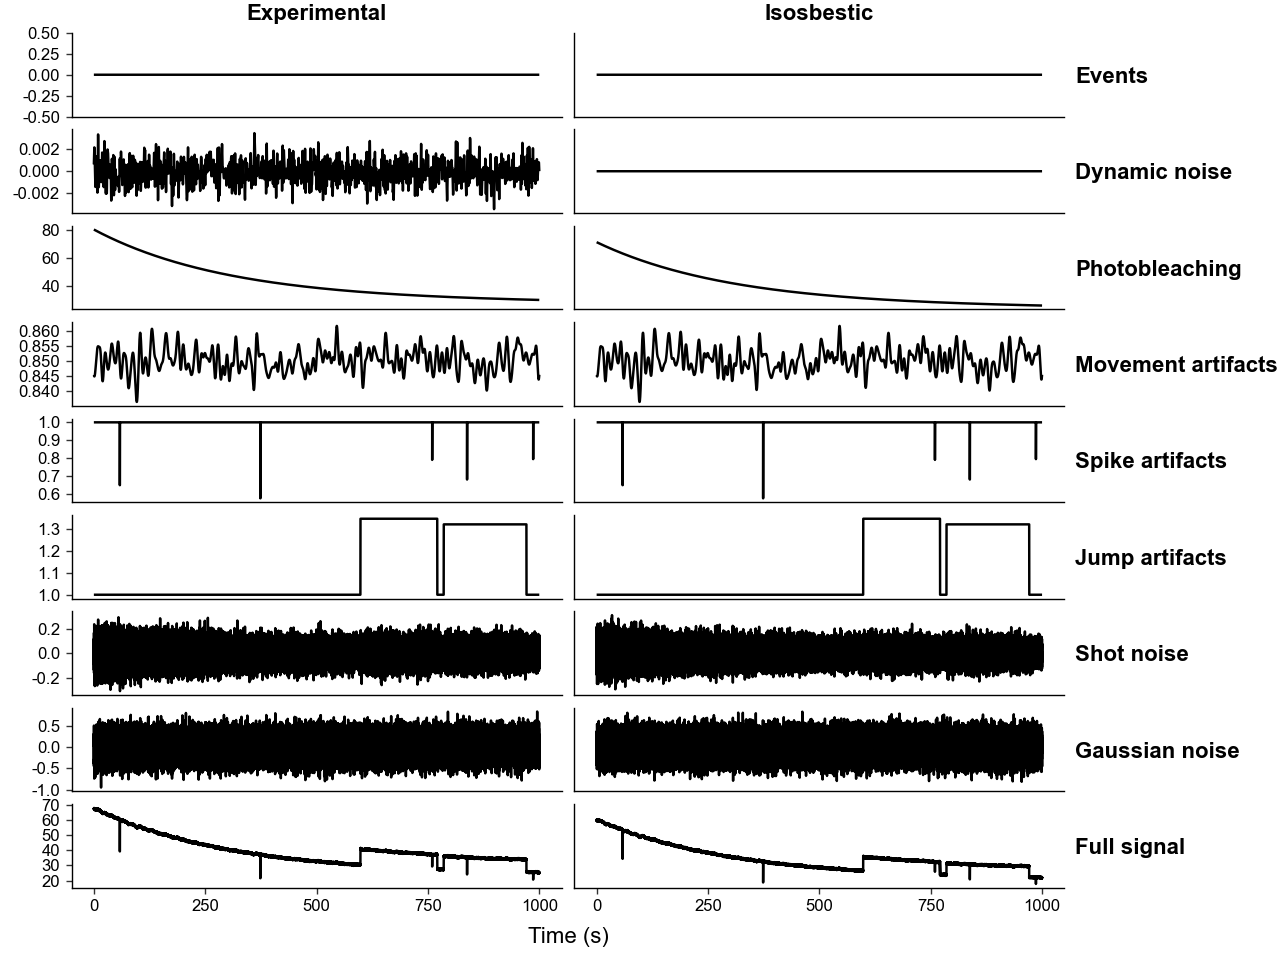

In [4]:
# plot all layers
sim.plot_layers(condensed=False)

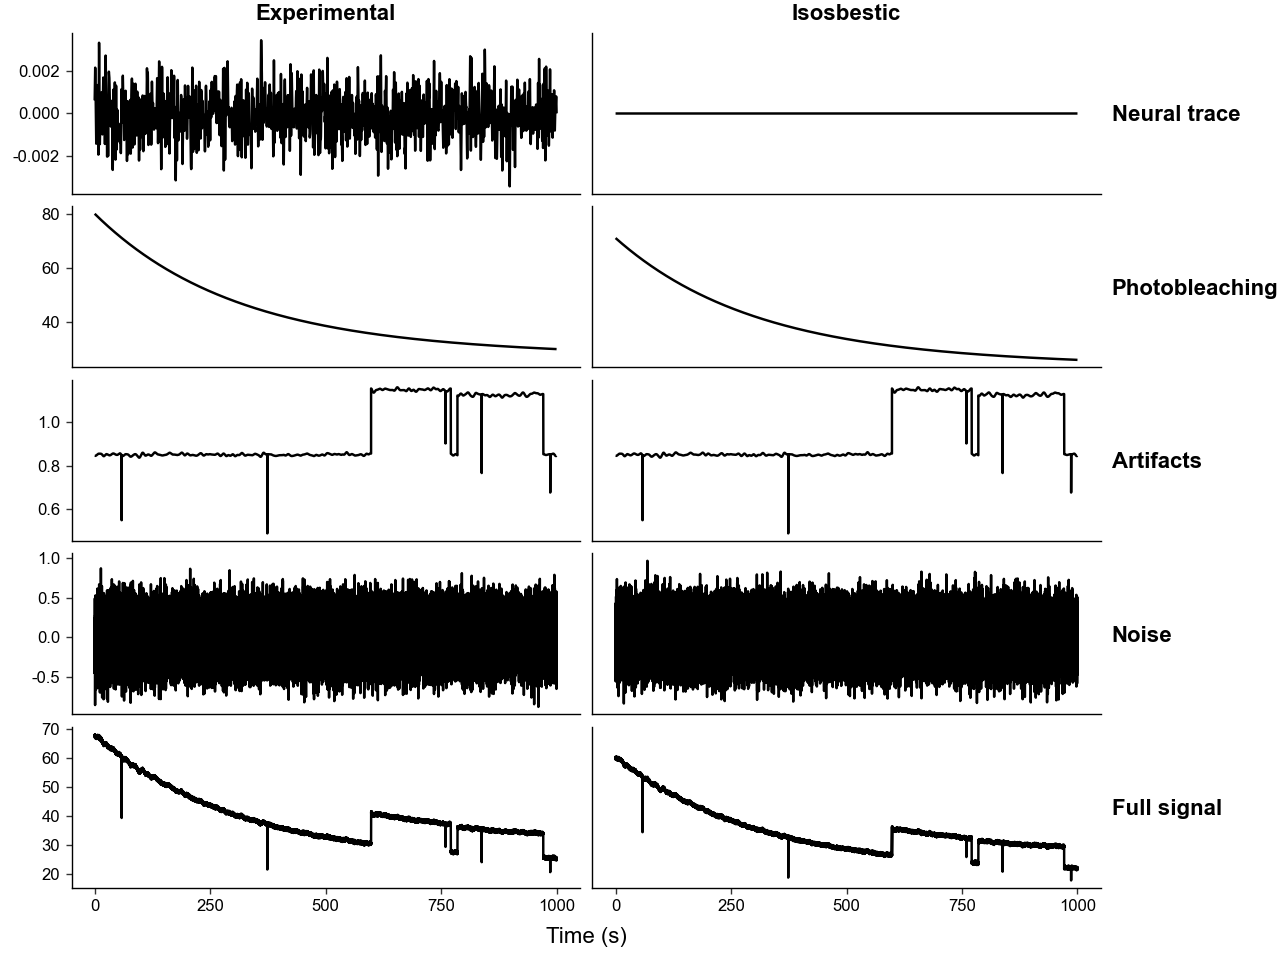

In [5]:
# plot condensed layers
sim.plot_layers(condensed=True)

Note that you can see how the intemediate layers are constructed from the base ones by comparing the condensed and full plots. 

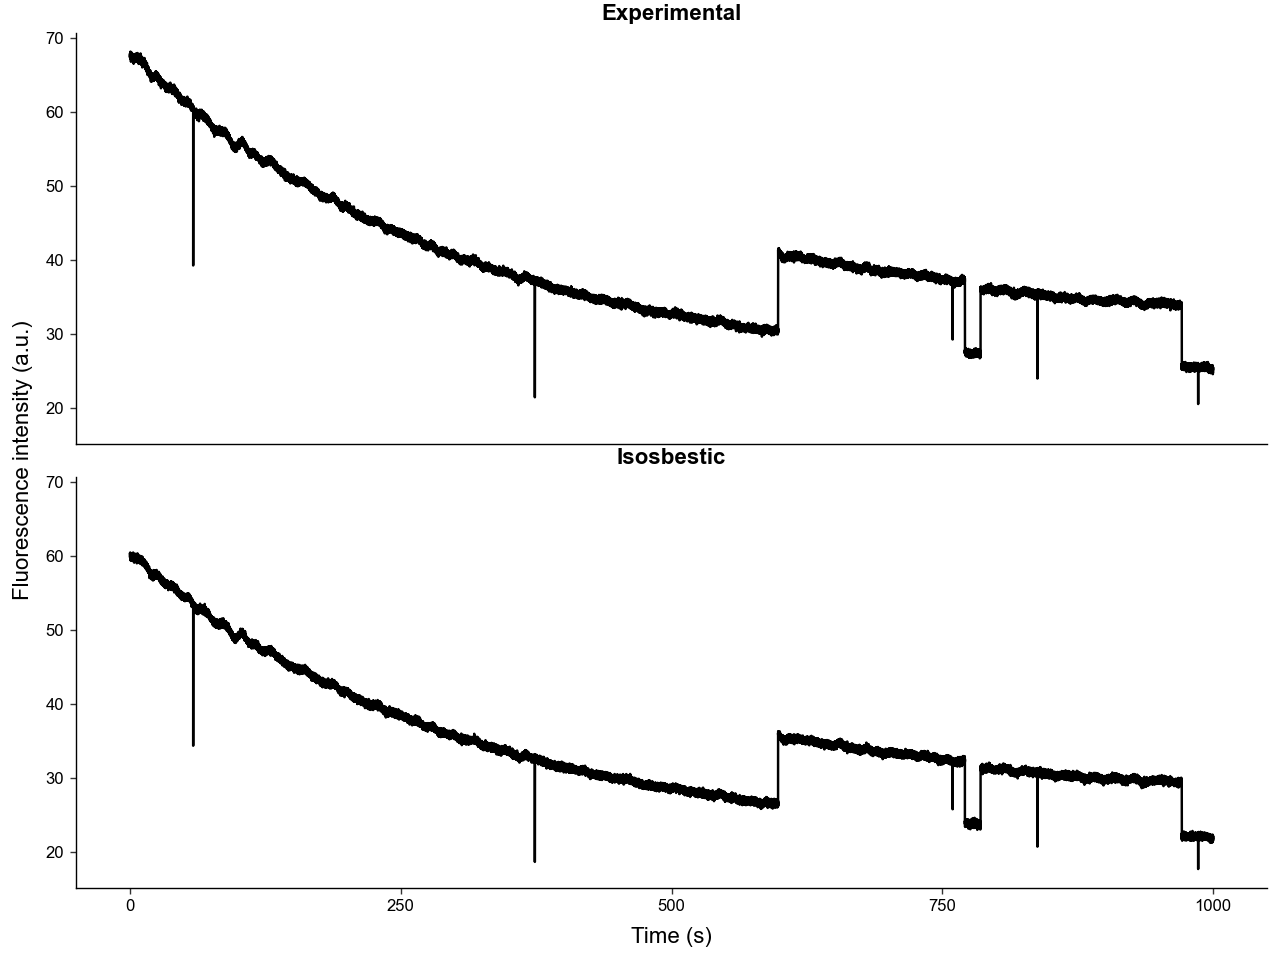

In [6]:
# plot final constructed traces
sim.plot_traces()

# 4. Controling Event Responses

For simulated data to be useful, we need to add "true signal", i.e. neural responses to events. We can do this both during the construction of ``SimulatedPhotometry`` and after.

Each event response is based on a kernel function, which take in a time-point array, an amplitude, and any number of other parameters, and produce a shape. Many kernel functions have been provided as static methods of ``SimulatedPhotometry``, all starting with "kernel_*".

Let's take a look at how the gamma kernel behaves.

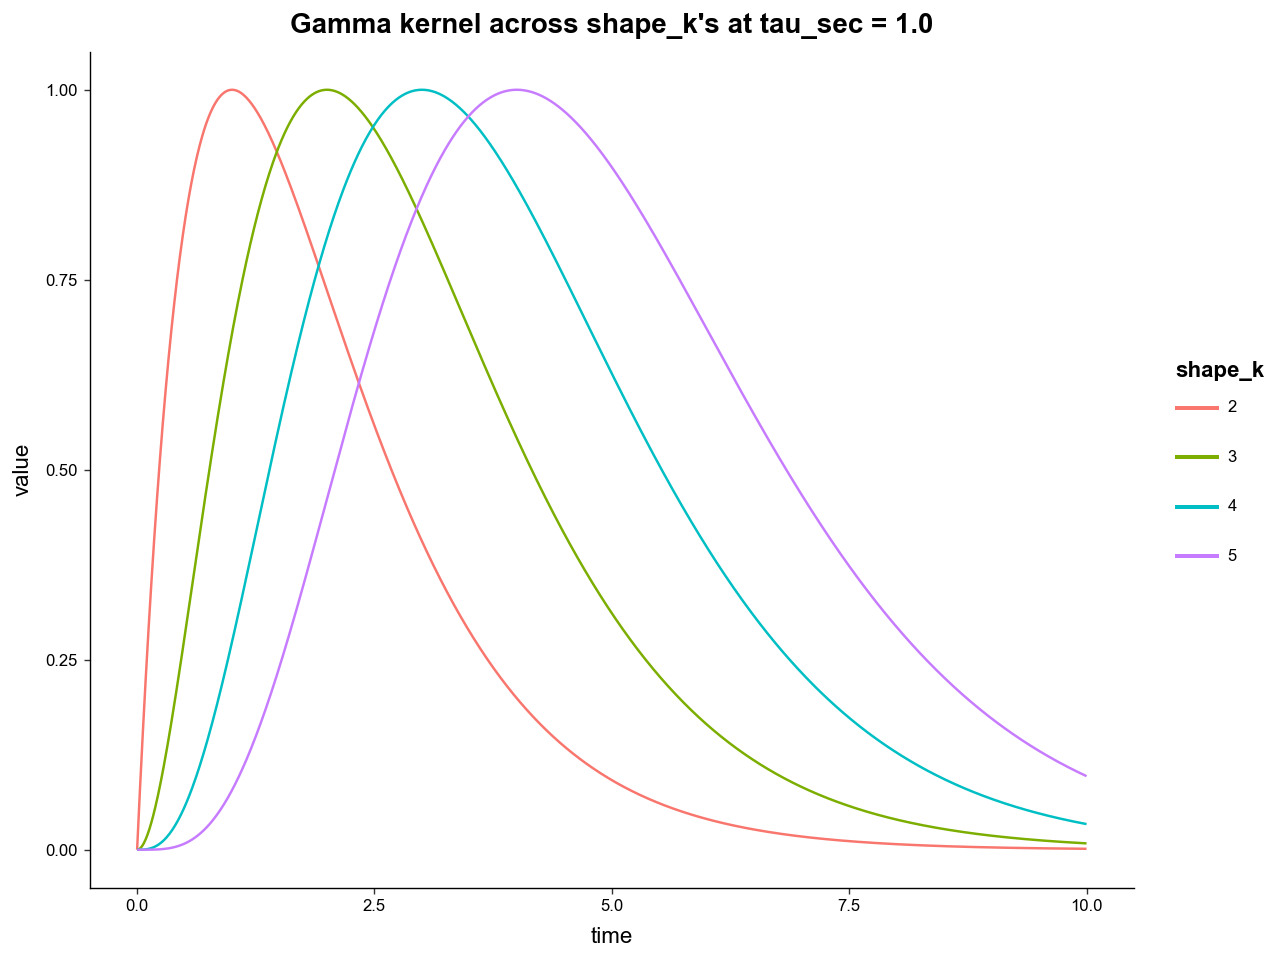

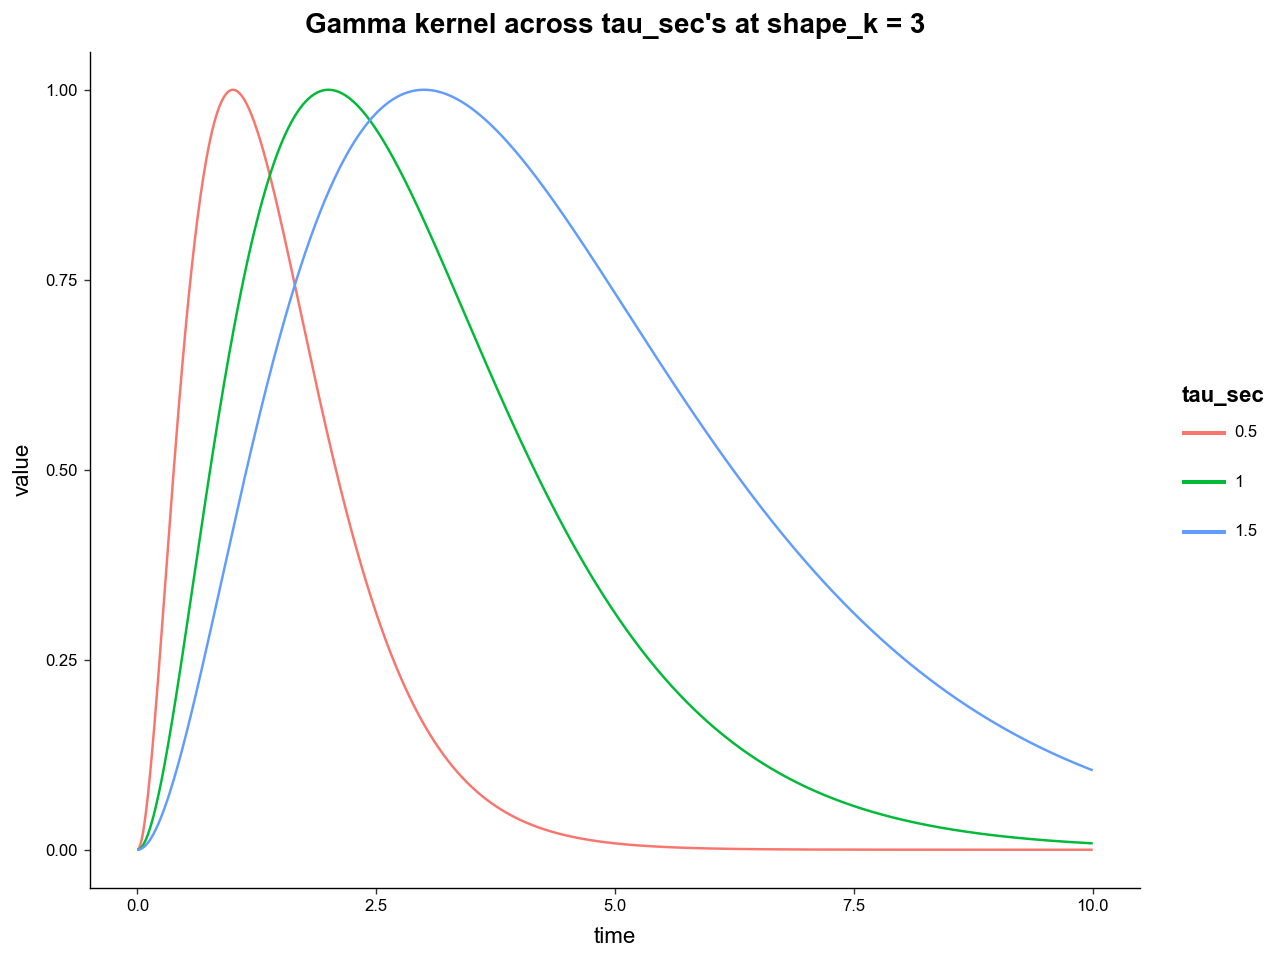

In [7]:
from PhoPro.utils.graphing import get_default_theme

def plot_gamma_across_ks(shape_ks: list[float] = [2, 3, 4, 5], tau_sec: float = 1.0, amplitude: float = 1.0) -> None:
    time = np.linspace(0, 10, 1000)

    dfs: list[pd.DataFrame] = []
    for shape_k in shape_ks:
        df_i = pd.DataFrame({
            'time' : time,
            'shape_k' : str(shape_k),
            'value' : SimulatedPhotometry.kernel_gamma(time, amplitude, shape_k, tau_sec)
        })
        dfs.append(df_i)

    df = pd.concat(dfs, ignore_index=True)

    p = (
        ggplot(df, aes(x='time', y='value', color='shape_k'))
        + geom_line()
        + labs(title=f'Gamma kernel across shape_k\'s at tau_sec = {tau_sec}')
        + get_default_theme()
    )
    p.show()

def plot_gamma_across_taus(tau_secs: list[float] = [0.5, 1, 1.5], shape_k: float = 3, amplitude: float = 1.0) -> None:
    time = np.linspace(0, 10, 1000)

    dfs: list[pd.DataFrame] = []
    for tau_sec in tau_secs:
        df_i = pd.DataFrame({
            'time' : time,
            'tau_sec' : str(tau_sec),
            'value' : SimulatedPhotometry.kernel_gamma(time, amplitude, shape_k, tau_sec)
        })
        dfs.append(df_i)

    df = pd.concat(dfs, ignore_index=True)

    p = (
        ggplot(df, aes(x='time', y='value', color='tau_sec'))
        + geom_line()
        + labs(title=f'Gamma kernel across tau_sec\'s at shape_k = {shape_k}')
        + get_default_theme()
    )
    p.show()


plot_gamma_across_ks()
plot_gamma_across_taus()

We see how the "shape_k" parameter controls the rate of increase, while the "tau_sec" parameter controls the rate of decay (roughly).

Now let's add some events to our simulated data.

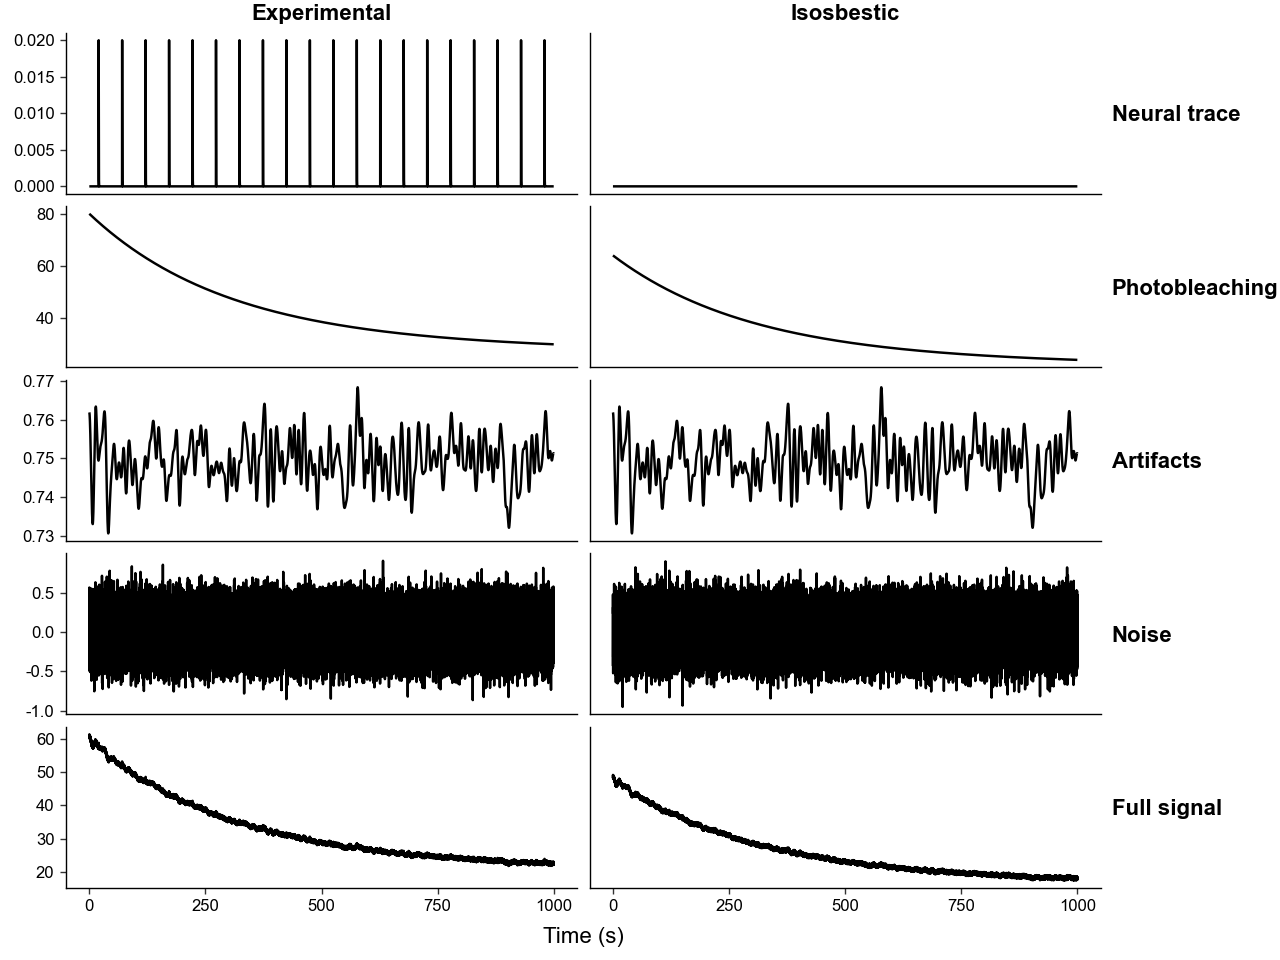

In [8]:
sim = SimulatedPhotometry.from_parameters(
    # --- event params ---
    # evenly spaced events of the E layer
    # these are best used as the "trial_cue" event
    n_events=20,
    event_label='trial_cue',

    # how much time in seconds to leave at either end of the trace
    event_buffer_sec=20.0,
    
    # the kernel function to generate event response architecture
    event_kernel=SimulatedPhotometry.kernel_gamma,
    # its amplitude
    event_amplitude=0.02,
    # other params for the kernel function
    event_kernel_params={ 'shape_k' : 3 , 'tau_sec' : 0.1},

    # --- other ---
    # length of experiment and sampling rate
    length_sec=1000,
    frequency=100,

    # parameters of photobleaching curves
    bleaching_params_exp = { 'alpha1': 50, 'alpha2': 20, 'tau1': 300, 'tau2': 10000, 'B_floor': 10 },
    iso_bleach_scale=0.8,
)

# now we can see the events in the experimental neural trace layer
sim.plot_layers()

We can add more events after construction using ``.add_event()`` and ``.add_event_relative_to()``. The latter is generally more useful for simulating experimental data since you can add events relative to a "trial_cue" event and choice lock multiple events.

Below we will add events to reconstruct the same experiment used as an example in the [Introduction]() tutorial, wherein:

*  A light turns on signifying the beginning of trial, represented by "trial_cue".

* Then the rat has between 2 and 4 seconds after the "trial_cue" to choose 1 of 2 levers that when pressed register as "lever1" and "lever2".

* "lever1" gives the rat a large food reward but there is a chance of the rat being shocked immediately after, represented by the "shock" event.

* "lever2" gives the rat a small food reward.

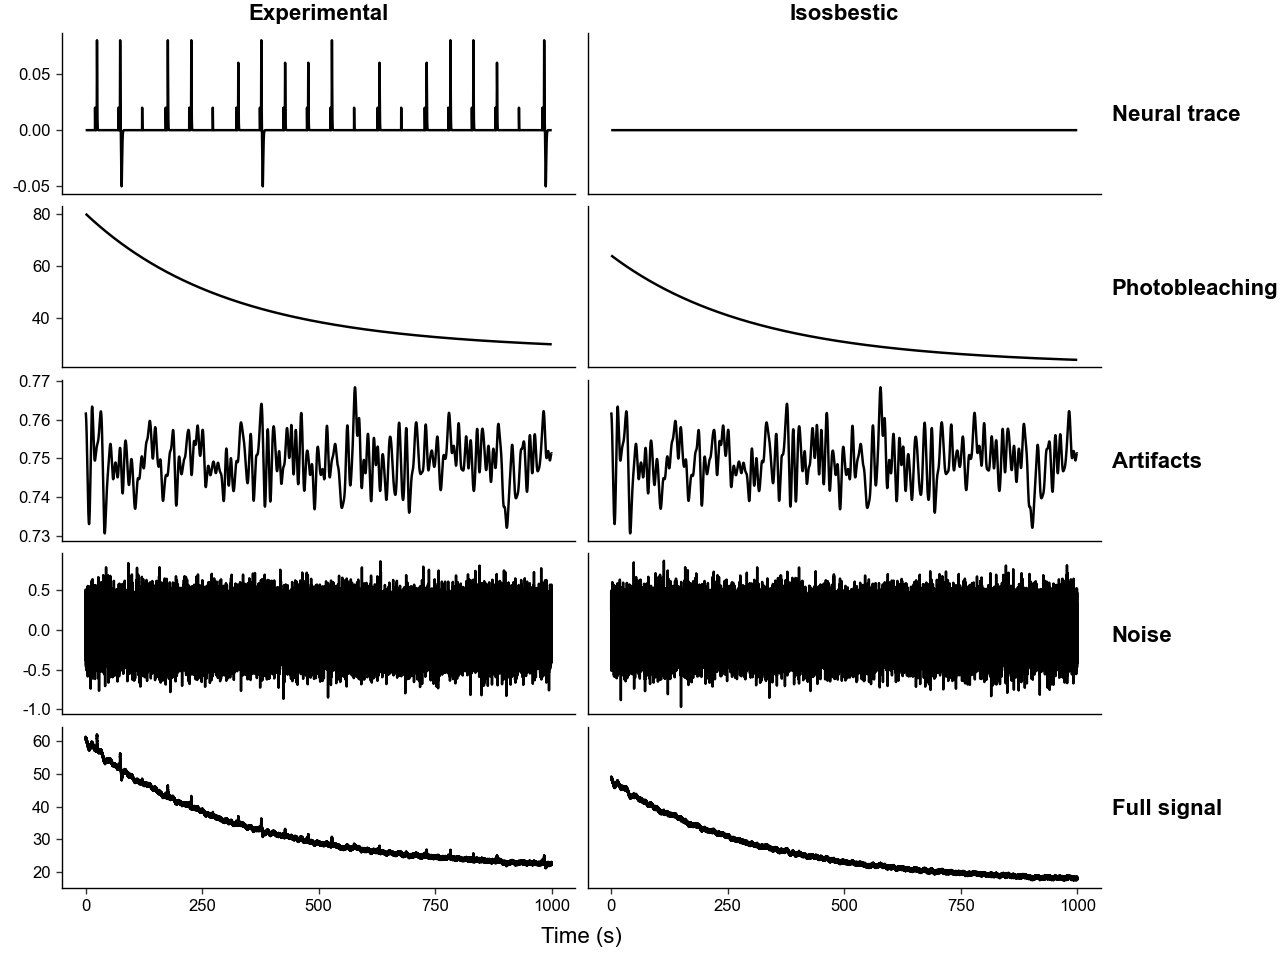

In [9]:
# add lever press events
sim.add_event_relative_to(

    relative_to='trial_cue',

    # time range after "relative_to" onset the new events can be placed
    time_range=(2, 4),

    # the overall probability of any event happening
    overall_prob=0.8,

    # event specifications
    labels=['lever1', 'lever2'],
    amplitudes=[0.08, 0.06],
    kernel_funcs=[
        SimulatedPhotometry.kernel_gamma, 
        SimulatedPhotometry.kernel_gamma
    ],
    kernel_params=[
        {'shape_k':5, 'tau_sec':0.2},
        {'shape_k':5, 'tau_sec':0.2},
    ],

    # the relative probabilties of the events
    choice_probs=[0.5, 0.5],
)

sim.add_event_relative_to(
    relative_to='lever1',
    time_range=(1, 1.5),
    overall_prob=0.5,
    labels=['shock'],
    amplitudes=[-0.05],
    kernel_funcs=[
        SimulatedPhotometry.kernel_gamma
    ],
    kernel_params=[
        {'shape_k':10, 'tau_sec':0.3},
    ],
)

# now we can see all the events in the experimental neural trace layer
sim.plot_layers()

# 5. Using Simulated Data

The main utility of simulating data is to allow for comparsions between processing methods with the ground truth of the neural signal known. The traces from ``SimulatedPhotometry`` can be directly exported to ``PhotometryExperiment``, while the true neural signal can be directly exported to ``PhotometryData``. After performing preprocessing and trial extraction on the ``PhotometryExperiment`` object, the resulting recovered signal in ``.trial_data`` can be compared to the exported true signal after normalization.

In [10]:
# similar simulated data as above
sim = SimulatedPhotometry.from_parameters(
    length_sec=1000,
    frequency=100,
    bleaching_params_exp = { 'alpha1': 50, 'alpha2': 20, 'tau1': 300, 'tau2': 10000, 'B_floor': 10 },
    iso_bleach_scale=0.8,

    n_events=20,
    event_label='trial_cue',
    event_buffer_sec=20.0,

    event_kernel=SimulatedPhotometry.kernel_gamma,
    event_amplitude=0.02,
    event_kernel_params={ 'shape_k' : 3 , 'tau_sec' : 0.1},
)

In [11]:
# export to Photometry experiment, process, and window
exp = sim.to_PhotometryExperiment()

exp.preprocess_signal(
    correction_method='dF/F',
    fit_using='IRLS'
)

exp.extract_trial_data(
    align_to='trial_cue',
    trial_bounds=(-1, 2),
)

recovered_signal = exp.trial_data

# get true signal, ensure that extraction parameters are the same
true_signal = sim.to_PhotometryData(
    align_to='trial_cue',
    trial_bounds=(-1, 2)
)

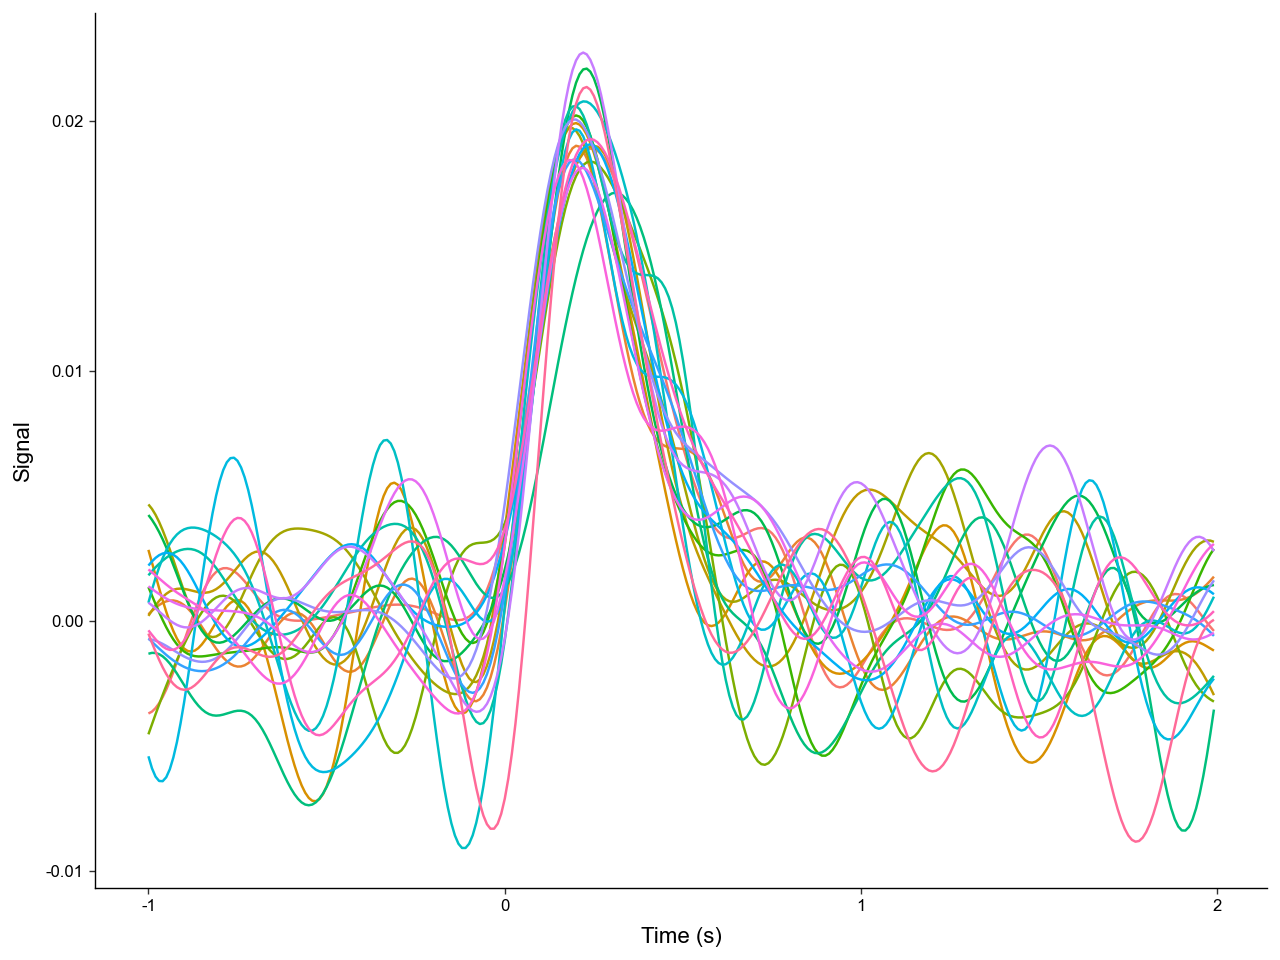

In [12]:
# visualize recovered signal
recovered_signal.plot_trials()

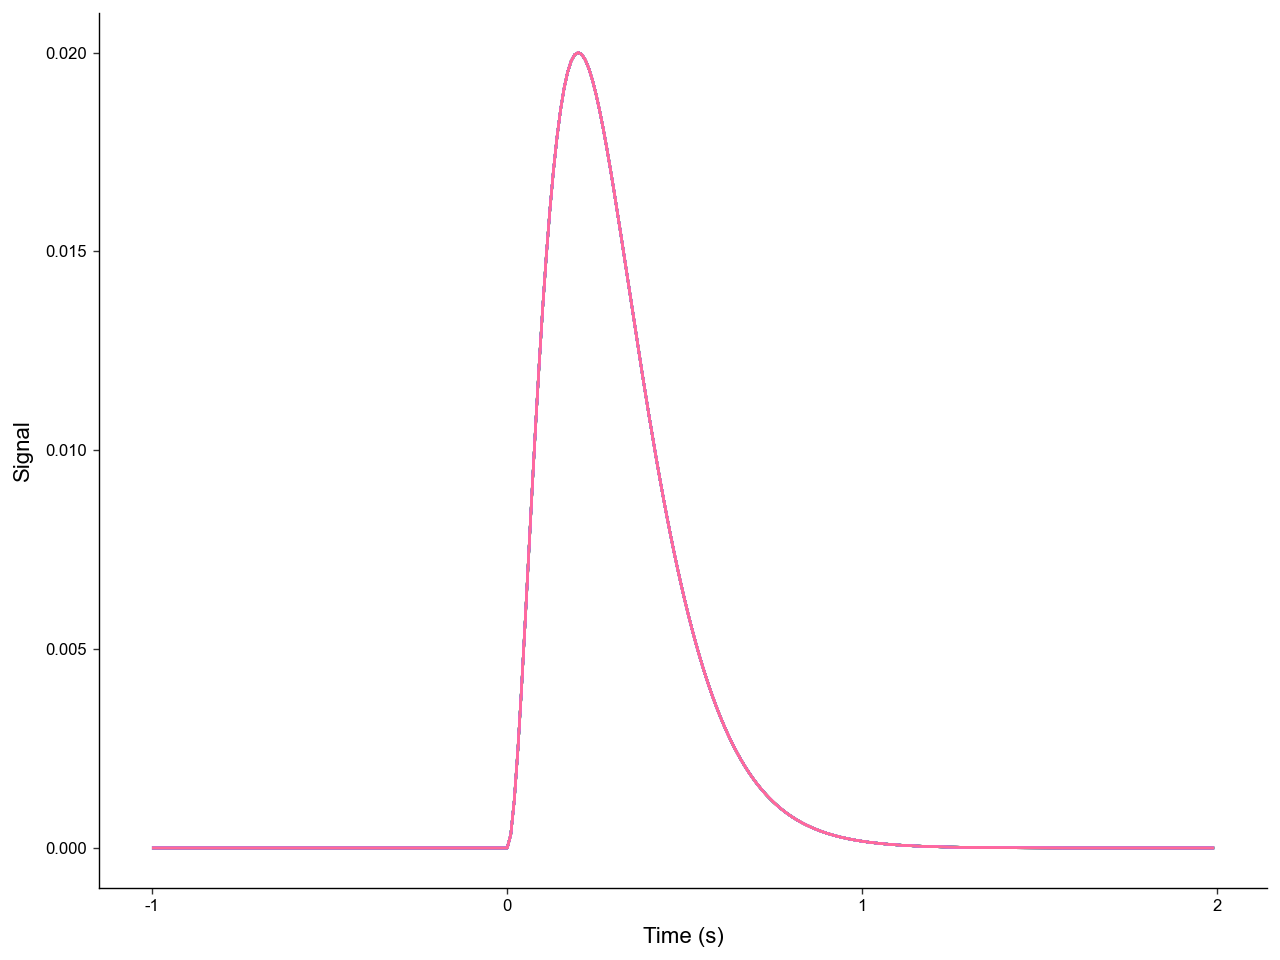

In [13]:
# visualize true signal
true_signal.plot_trials()

Now lets compute some metrics on how well we recovered the true signal.

In [14]:
# since all true signals are the same we can collapse them
# then we will get the signals as arrays from the .X attribute
true_arr = true_signal.collapse(None).X
recoved_arr = recovered_signal.X

# compute error metrics
err = recoved_arr - true_arr
rmsd = np.sqrt(np.mean(err**2, axis=1))
mae = np.mean(np.abs(err), axis=1)

# add them as columns in .obs
recovered_signal.obs['rmsd'] = rmsd
recovered_signal.obs['mae'] = mae

# print error information
print(
    f'RMSD = {np.mean(rmsd):.4f} +/- {np.std(rmsd):.4f}\n'
    f'MAE = {np.mean(mae):.4f} +/- {np.std(mae):.4f}'
)

RMSD = 0.0024 +/- 0.0007
MAE = 0.0019 +/- 0.0006


By comparing the error metrics of multiple different preprocessing methods we can better understand what methods are most accurate for different types of real-world data.

# 6. A peek behind the curtain

The example data used in the [Introduction]() tutorial was generated by the code below:

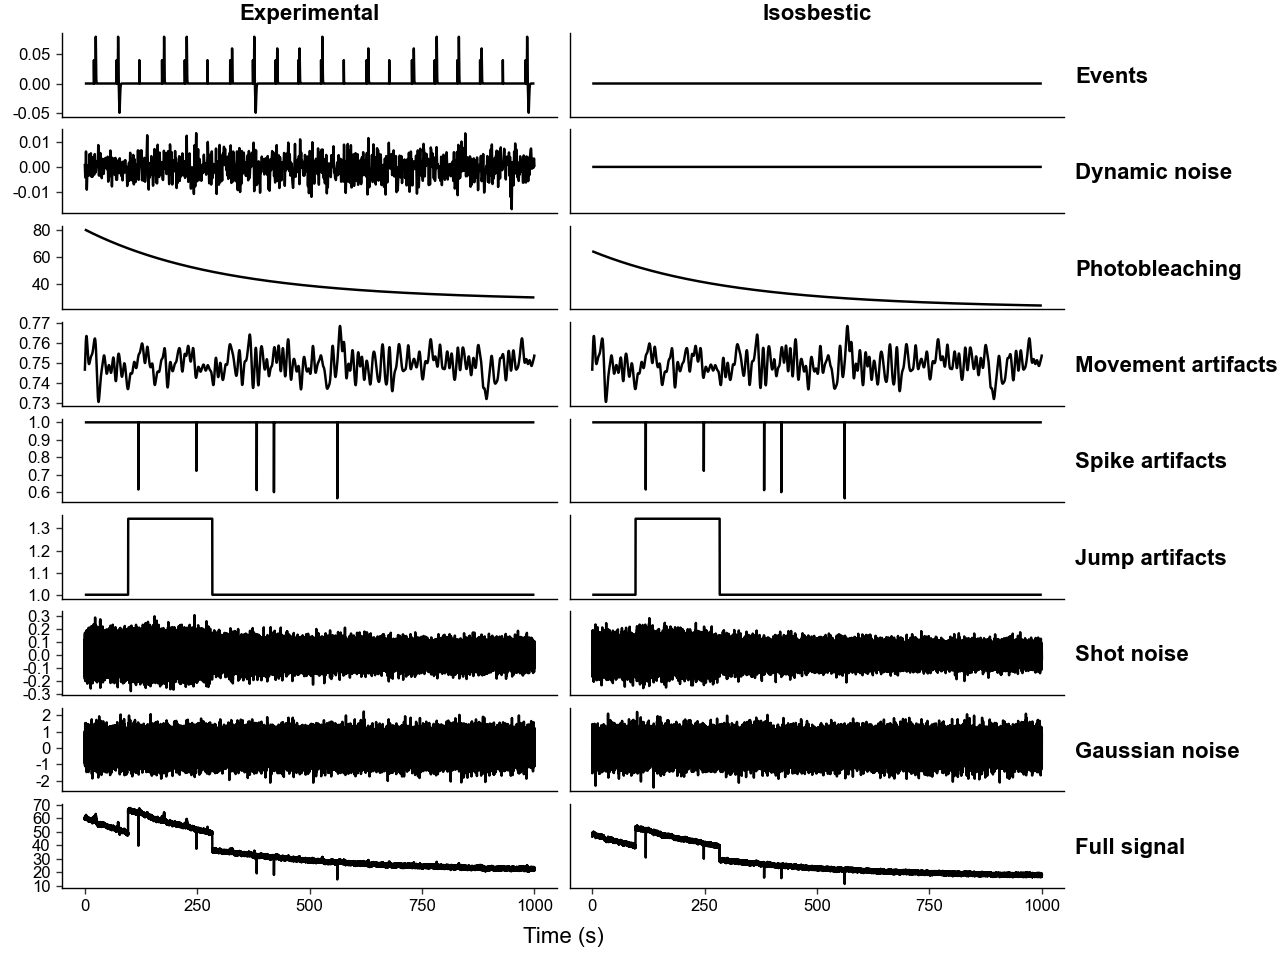

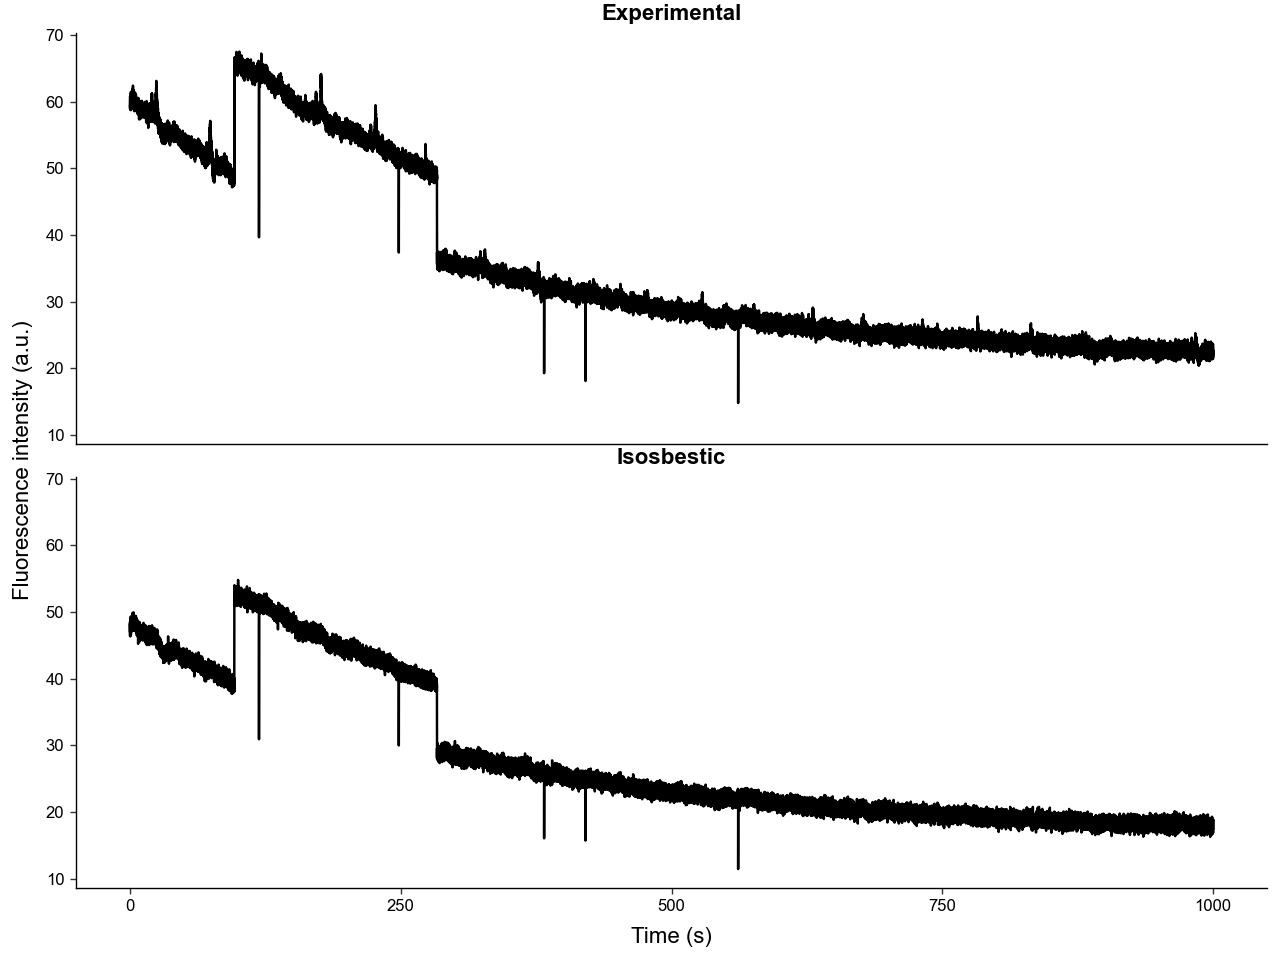

In [15]:
sim = SimulatedPhotometry.from_parameters(
    length_sec=1000,
    frequency=100,

    bleaching_params_exp = { 'alpha1': 50, 'alpha2': 20, 'tau1': 300, 'tau2': 10000, 'B_floor': 10 },
    iso_bleach_scale=0.8,
    iso_bleach_offset=None,

    event_label='trial_cue',
    n_events=20,
    event_kernel=SimulatedPhotometry.kernel_gamma,
    event_amplitude=0.04,
    event_kernel_params={'tau_sec':0.1},
    event_buffer_sec=20.0,

    movement_attenuation=0.5,
    attenuation_cutoff_hz=0.1,

    photons_per_unit=1e4,
    gaussian_noise_scale=0.5,

    dynamic_noise_amplitude=0.004,
    dynamic_noise_center=0.0,
    dynamic_noise_frequency=1.0,

    n_spike_artifacts=5,
    spike_amplitude_range=(-0.5, -0.2),

    n_jump_artifacts=1,
    jump_amplitude_range=(0.3, 0.35),
    jump_duration_range=(100, 200),

)

sim.add_event_relative_to(
    relative_to='trial_cue',
    time_range=(2, 4),
    overall_prob=0.8,
    labels=['lever1', 'lever2'],
    choice_probs=[0.5, 0.5],
    amplitudes=[0.08, 0.06],
    kernel_funcs=[
        SimulatedPhotometry.kernel_gamma, 
        SimulatedPhotometry.kernel_gamma
    ],
    kernel_params=[
        {'shape_k':5, 'tau_sec':0.2},
        {'shape_k':5, 'tau_sec':0.2},
    ],
)

sim.add_event_relative_to(
    relative_to='lever1',
    time_range=(1, 1.5),
    overall_prob=0.5,
    labels=['shock'],
    amplitudes=[-0.05],
    kernel_funcs=[
        SimulatedPhotometry.kernel_gamma
    ],
    kernel_params=[
        {'shape_k':10, 'tau_sec':0.3},
    ],
)

sim.plot_layers(condensed=False).show()
sim.plot_traces().show()